In [1]:
import pandas as pd

In [2]:
invoice_data = pd.read_csv("data/OnlineRetail.csv", encoding='ISO-8859-1')
invoice_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [3]:
invoice_data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
invoice_data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
invoice_data = invoice_data.dropna(subset=['CustomerID'])

In [6]:
invoice_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [7]:
invoice_data[invoice_data['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


Observed that records with missing Description also had missing CustomerID. Since customer-level analysis requires valid customer identifiers, these records were removed as part of handling missing CustomerID.

In [8]:
descriptions_list = invoice_data['Description'].unique().tolist()

In [9]:
print(descriptions_list)

['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT', 'ASSORTED COLOUR BIRD ORNAMENT', "POPPY'S PLAYHOUSE BEDROOM ", "POPPY'S PLAYHOUSE KITCHEN", 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'IVORY KNITTED MUG COSY ', 'BOX OF 6 ASSORTED COLOUR TEASPOONS', 'BOX OF VINTAGE JIGSAW BLOCKS ', 'BOX OF VINTAGE ALPHABET BLOCKS', 'HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD', 'RECIPE BOX WITH METAL HEART', 'DOORMAT NEW ENGLAND', 'JAM MAKING SET WITH JARS', 'RED COAT RACK PARIS FASHION', 'YELLOW COAT RACK PARIS FASHION', 'BLUE COAT RACK PARIS FASHION', 'BATH BUILDING BLOCK WORD', 'ALARM CLOCK BAKELIKE PINK', 'ALARM CLOCK BAKELIKE RED ', 'ALARM CLOCK BAKELIKE GREEN', 'PANDA AND BUNNIES STICKER SHEET', 'STARS GIFT TAPE ', 'INFLATABLE POLITICAL GLOBE ', 'VINTAGE 

In [10]:
invoice_data = invoice_data.drop('Description', axis=1)

In [11]:
invoice_data

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,4,12/9/2011 12:50,4.15,12680.0,France


Dropped 'Description' as it is not required for RFM analysis and does not contribute to customer-level aggregation

In [12]:
invoice_data[invoice_data['Quantity']<0]

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...
540449,C581490,23144,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


Observed negative values in the Quantity column. Since RFM analysis focuses on purchase behavior, transactions with non-positive quantity were excluded to avoid distortion in customer-level metrics.

In [13]:
invoice_data = invoice_data[invoice_data['Quantity'] > 0]

In [14]:
invoice_data

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,4,12/9/2011 12:50,4.15,12680.0,France


In [15]:
invoice_data[invoice_data['UnitPrice']<0]

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


Observed negative values in the Quantity column. Since RFM analysis focuses on purchase behavior, transactions with non-positive quantity were excluded to avoid distortion in customer-level metrics.

In [16]:
(invoice_data['UnitPrice'] == 0).sum()

40

In [17]:
invoice_data = invoice_data[invoice_data['UnitPrice'] > 0]

In [18]:
(invoice_data['UnitPrice'] <= 0).sum()

0

Removed transactions with non-positive unit price as they do not contribute to monetary value and can distort customer segmentation based on revenue.

In [19]:
invoice_data = invoice_data.copy()
invoice_data['TotalPrice'] = invoice_data['Quantity'] * invoice_data['UnitPrice']

In [20]:
invoice_data.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [21]:
invoice_data['InvoiceDate'] = pd.to_datetime(invoice_data['InvoiceDate'])

In [22]:
reference_date = invoice_data['InvoiceDate'].max() + pd.Timedelta(days=1)

In [23]:
print(reference_date)

2011-12-10 12:50:00


In [24]:
rfm = invoice_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [25]:
rfm.head()

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [26]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

In [27]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [28]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


## Hypothesis 1
Customers who are less frequent make more premium purchases lasting long time

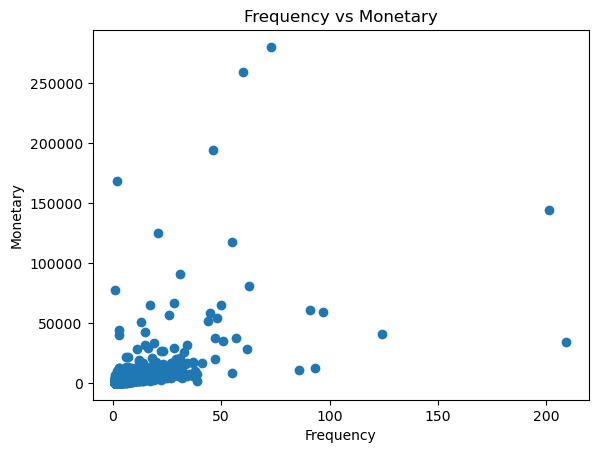

In [29]:
import matplotlib.pyplot as plt

plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Frequency vs Monetary')
plt.show()

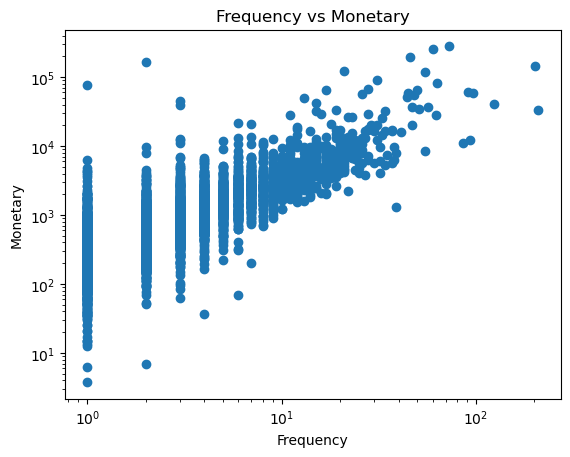

In [30]:
plt.xscale('log')
plt.yscale('log')
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Frequency vs Monetary')
plt.show()

A positive relationship is observed between frequency and monetary value, where higher frequency customers tend to spend more. However, there is significant variability, indicating that not all frequent customers are high spenders. A small number of customers contribute disproportionately high revenue.

## Hypothesis 2
Both very recent and customer who did not vist for a long time will have less monetary value

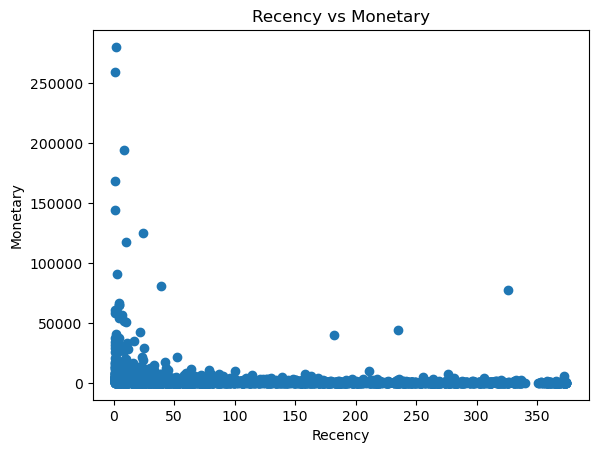

In [31]:
plt.scatter(rfm['Recency'], rfm['Monetary'])
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Recency vs Monetary')
plt.show()

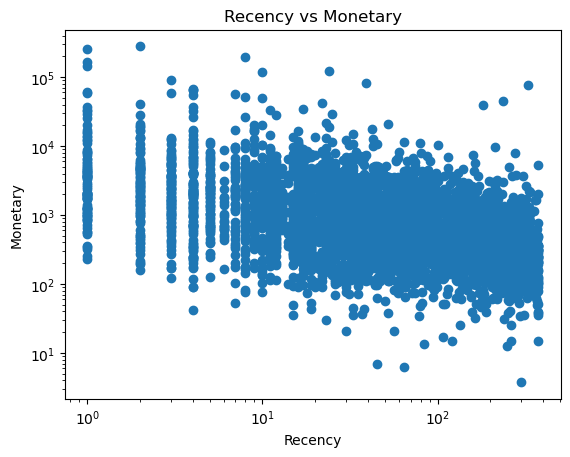

In [32]:
plt.xscale('log')
plt.yscale('log')
plt.scatter(rfm['Recency'], rfm['Monetary'])
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Recency vs Monetary')
plt.show()

A negative relationship is observed between recency and monetary value, where more recent customers tend to have higher spending, while customers with higher recency (inactive users) generally contribute lower revenue.

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

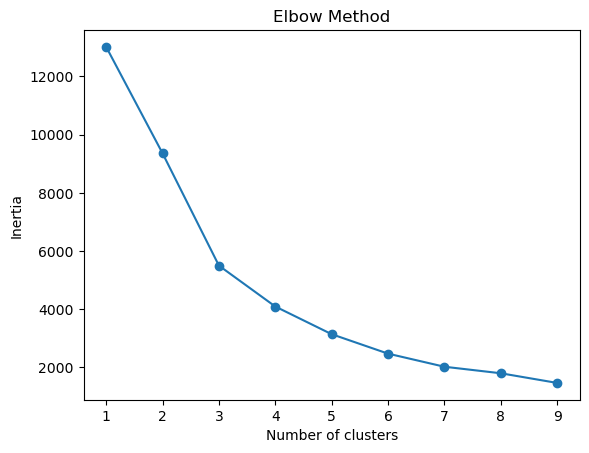

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [36]:
rfm.groupby('Cluster').mean()

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15282.157846,40.983906,4.852677,2012.111620
1,15354.225984,246.023788,1.582800,631.141410
2,15310.642857,7.142857,80.214286,122888.407143


In [37]:
rfm['Cluster'].value_counts()

Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64

Customer segmentation reveals three distinct groups: high-value customers with frequent and recent purchases, mid-value customers with moderate engagement, and low-value customers with low frequency and high inactivity. A small segment of high-value customers contributes disproportionately to overall revenue.

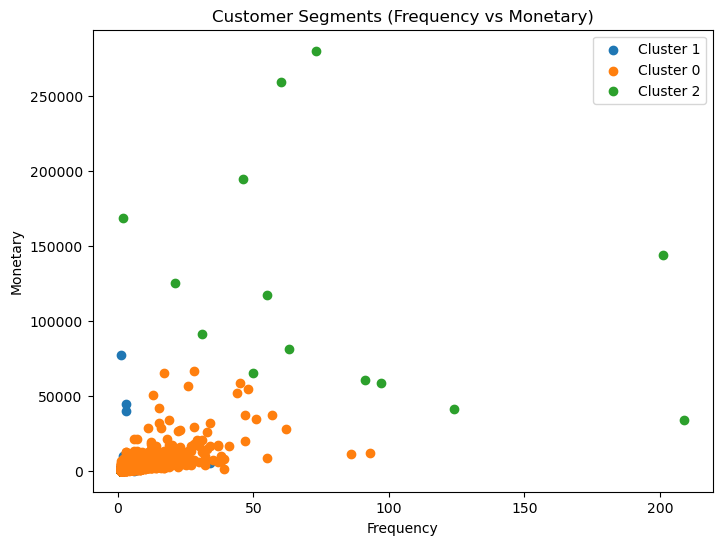

In [40]:
plt.figure(figsize=(8,6))

for cluster in rfm['Cluster'].unique():
    subset = rfm[rfm['Cluster'] == cluster]
    plt.scatter(subset['Frequency'], subset['Monetary'], label=f'Cluster {cluster}')

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segments (Frequency vs Monetary)')
plt.legend()
plt.show()

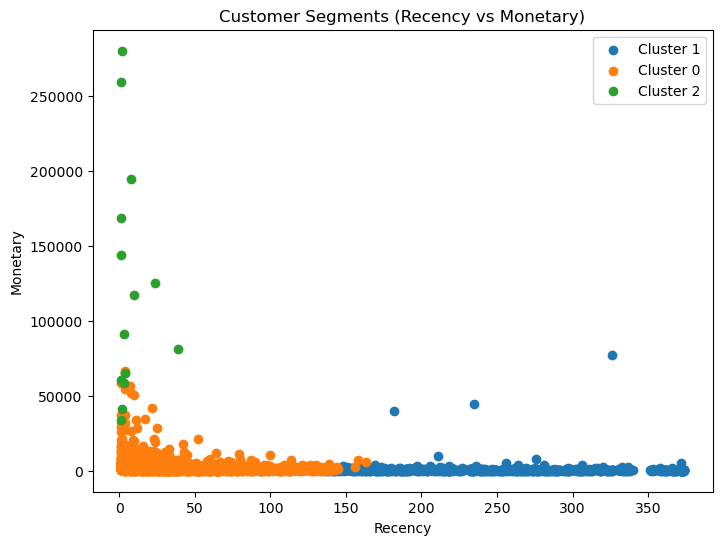

In [41]:
plt.figure(figsize=(8,6))

for cluster in rfm['Cluster'].unique():
    subset = rfm[rfm['Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Monetary'], label=f'Cluster {cluster}')

plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments (Recency vs Monetary)')
plt.legend()
plt.show()

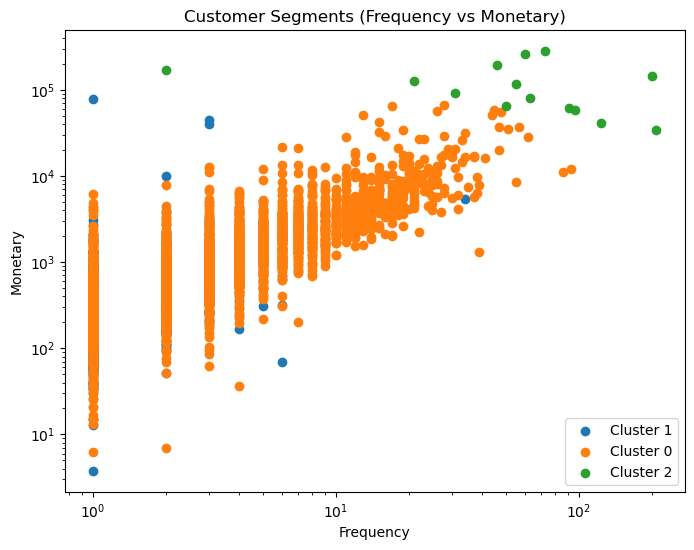

In [42]:
plt.figure(figsize=(8,6))

for cluster in rfm['Cluster'].unique():
    subset = rfm[rfm['Cluster'] == cluster]
    plt.scatter(subset['Frequency'], subset['Monetary'], label=f'Cluster {cluster}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segments (Frequency vs Monetary)')
plt.legend()
plt.show()

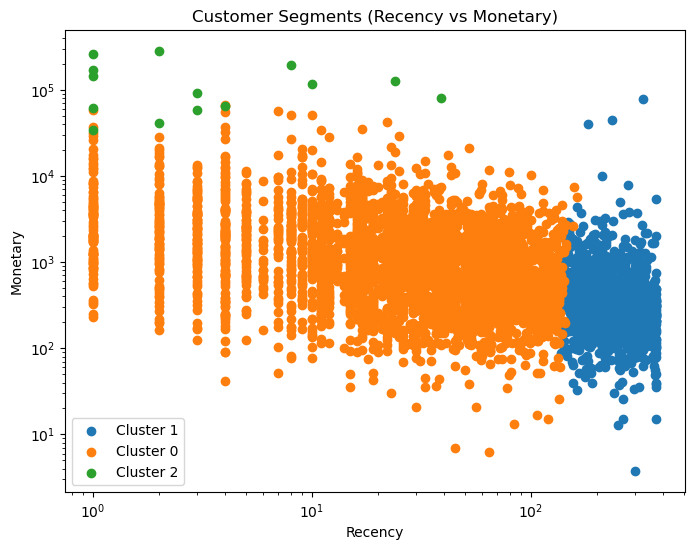

In [43]:
plt.figure(figsize=(8,6))

for cluster in rfm['Cluster'].unique():
    subset = rfm[rfm['Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Monetary'], label=f'Cluster {cluster}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments (Recency vs Monetary)')
plt.legend()
plt.show()